# Logistics Regression For Customer Churn Prediction

In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

## load data

In [57]:
data = pd.read_csv('CSV_file\\churn_data.csv')

In [58]:
data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 495.3+ KB


In [60]:
data.dtypes

customerID           object
tenure                int64
PhoneService         object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [61]:
data.isnull().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [62]:
data.shape

(7043, 9)

### checks various type of value for categorical features for encoding

In [63]:
print(data['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [64]:
print(data['PaperlessBilling'].value_counts())

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


In [65]:
print(data['Contract'].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [66]:
print(data['PaymentMethod'].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [67]:
data_ob = data.select_dtypes(include = ['object'])

In [68]:
data_ob.columns

Index(['customerID', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [69]:
data_ob.shape[1]

7

### data Encoding

In [70]:
label_encoders = {}
for cols in data.select_dtypes(include = ['object']).columns:
    if cols != 'customerID':
        la = LabelEncoder()
        data[cols] = la.fit_transform(data[cols])
        label_encoders[cols] = la
    else:
        print('CustomerID encounter')

CustomerID encounter


In [71]:
label_encoders

{'PhoneService': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'TotalCharges': LabelEncoder(),
 'Churn': LabelEncoder()}

In [72]:
data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,0,1,2,29.85,2505,0
1,5575-GNVDE,34,1,1,0,3,56.95,1466,0
2,3668-QPYBK,2,1,0,1,3,53.85,157,1
3,7795-CFOCW,45,0,1,0,0,42.30,1400,0
4,9237-HQITU,2,1,0,1,2,70.70,925,1


In [73]:
data.dtypes

customerID           object
tenure                int64
PhoneService          int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
Churn                 int64
dtype: object

### define independent and dependent variables

In [74]:
X = data.drop(columns = ['customerID', 'Churn'])
Y = data['Churn']

In [75]:
X.head()

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,0,1,2,29.85,2505
1,34,1,1,0,3,56.95,1466
2,2,1,0,1,3,53.85,157
3,45,0,1,0,0,42.30,1400
4,2,1,0,1,2,70.70,925


In [76]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

### Spliting the datasets

In [77]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [78]:
X_train.shape, X_test.shape

((5634, 7), (1409, 7))

In [79]:
Y_train.shape, Y_test.shape

((5634,), (1409,))

### Standardize the features

In [80]:
st = StandardScaler()
X_train = st.fit_transform(X_train)

In [81]:
X_train

array([[-4.65683364e-01,  3.29573443e-01,  3.72908354e-01, ...,
         1.33926673e+00, -4.73723375e-04, -1.40800618e+00],
       [ 8.85536787e-01,  3.29573443e-01,  1.57759050e+00, ...,
        -1.47094882e+00,  1.07475386e+00,  5.58360318e-01],
       [-1.28460467e+00, -3.03422506e+00, -8.31773795e-01, ...,
         4.02528212e-01, -1.37649913e+00, -7.02892284e-01],
       ...,
       [-8.34197950e-01,  3.29573443e-01, -8.31773795e-01, ...,
         4.02528212e-01, -1.45294499e+00, -3.21706651e-01],
       [-8.34197950e-01,  3.29573443e-01, -8.31773795e-01, ...,
         4.02528212e-01,  1.14953785e+00, -1.53524478e+00],
       [-2.60953038e-01,  3.29573443e-01,  3.72908354e-01, ...,
        -5.34210304e-01, -1.49781538e+00,  3.30921324e-01]],
      shape=(5634, 7))

In [82]:
X_test = st.transform(X_test)

In [83]:
X_test

array([[-1.28460467, -3.03422506, -0.83177379, ...,  0.40252821,
        -1.33162874, -0.64775556],
       [ 0.35323794,  0.32957344, -0.83177379, ..., -1.47094882,
        -1.31667194,  1.72630461],
       [ 0.80364466,  0.32957344,  1.5775905 , ...,  1.33926673,
        -1.51277218, -1.69588351],
       ...,
       [-0.62946762,  0.32957344,  0.37290835, ..., -1.47094882,
        -1.49449165, -0.21726497],
       [ 1.49972776, -3.03422506,  1.5775905 , ..., -0.5342103 ,
        -0.69513389, -0.37631322],
       [-1.28460467, -3.03422506, -0.83177379, ...,  1.33926673,
        -1.11392424, -0.30156054]], shape=(1409, 7))

## Create logistics model

In [84]:
### initialize the model
model = LogisticRegression()

In [85]:
### Train the model
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [86]:
### make predictions
y_pred = model.predict(X_test)

In [87]:
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [88]:
Y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

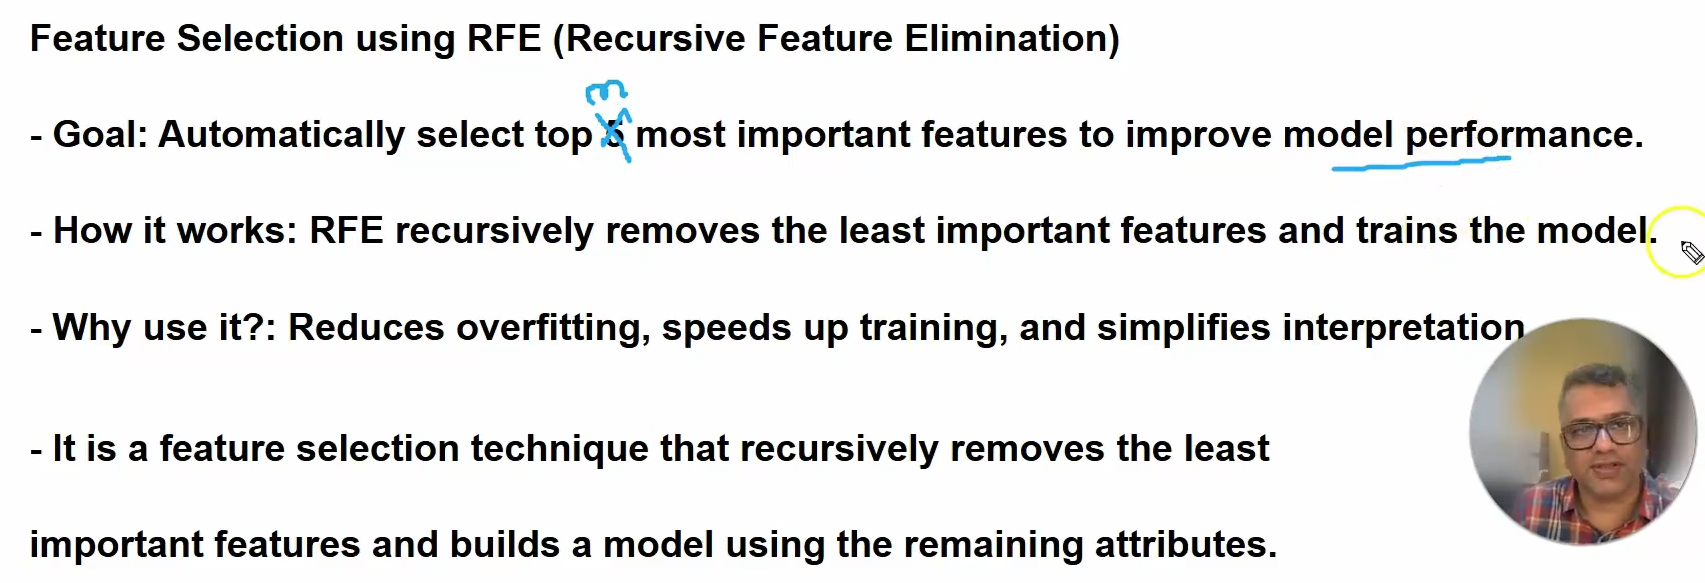

In [89]:
from sklearn.feature_selection import RFE # it is class

In [90]:
rfe_model = LogisticRegression()

rfe = RFE(estimator = rfe_model, n_features_to_select = 5)

In [91]:
# Fit RFE
rfe.fit(X_train, Y_train)

selected_features = rfe.support_
# transform datasets
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

In [92]:
print(selected_features)

[ True  True  True  True False  True False]


In [93]:
print(rfe.ranking_) # rank the feature based on importance

[1 1 1 1 3 1 2]


In [94]:
model.fit(X_train_rfe, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [95]:
y_pred_rfe = model.predict(X_test_rfe)

In [96]:
y_pred_rfe

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [111]:
Y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

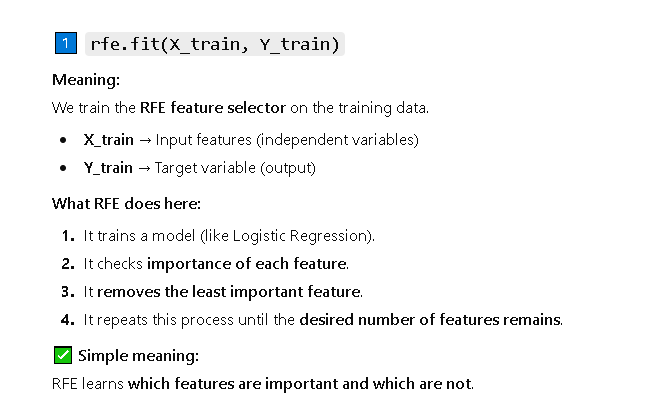

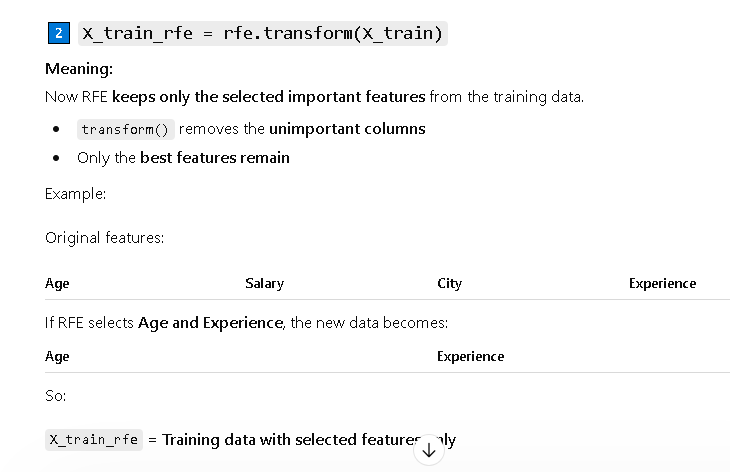

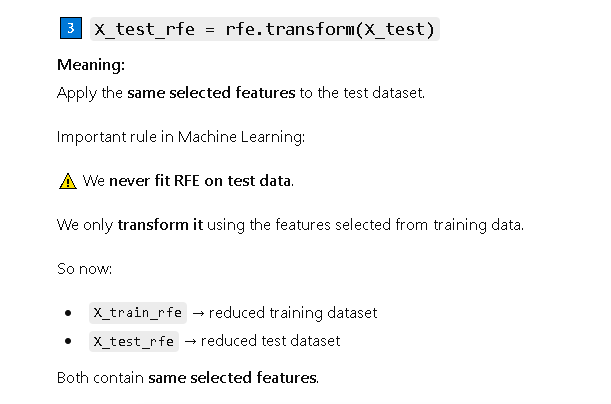

### Model Evaluation

In [97]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

In [98]:
print('Confusion matrix:\n', confusion_matrix(Y_test, y_pred_rfe))

Confusion matrix:
 [[937  99]
 [170 203]]


In [99]:
print(f'Accuracy of our model: {accuracy_score(Y_test, y_pred_rfe)}')

Accuracy of our model: 0.8090844570617459


In [100]:
print('Accuracy: ', accuracy_score(Y_test, y_pred))

Accuracy:  0.8062455642299503


In [101]:
## cal. senstivity
print('Sensitivity: ', recall_score(Y_test, y_pred_rfe))

Sensitivity:  0.5442359249329759


In [102]:
# cal. specificity
tn, fp, fn, tp = confusion_matrix(Y_test, y_pred_rfe).ravel()

In [103]:
result = tn/(tn+fp)
print('Specificity: ', result)

Specificity:  0.9044401544401545


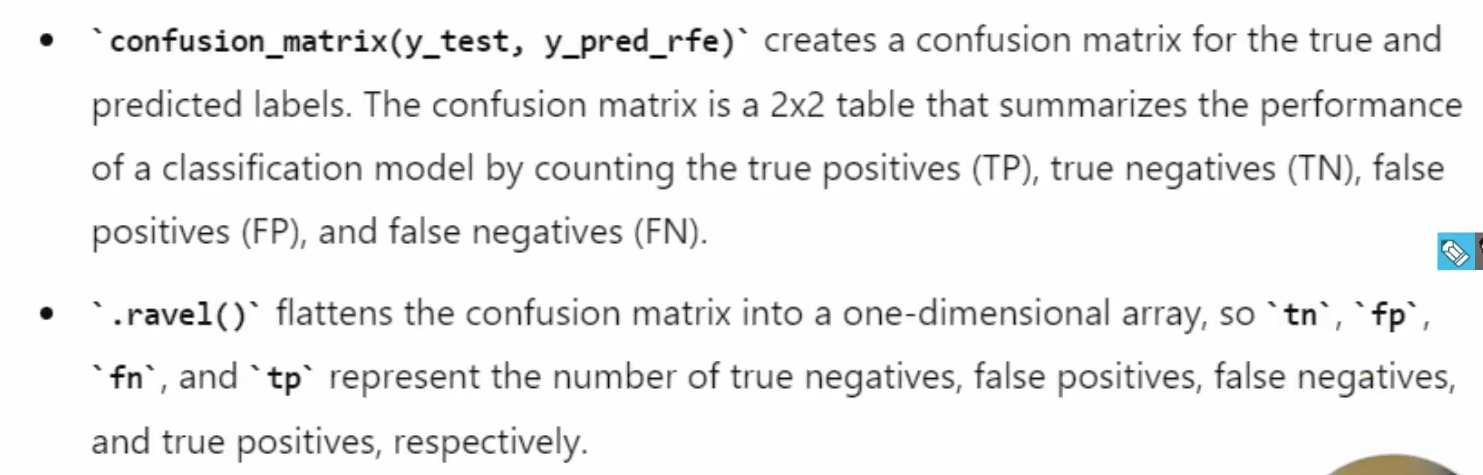

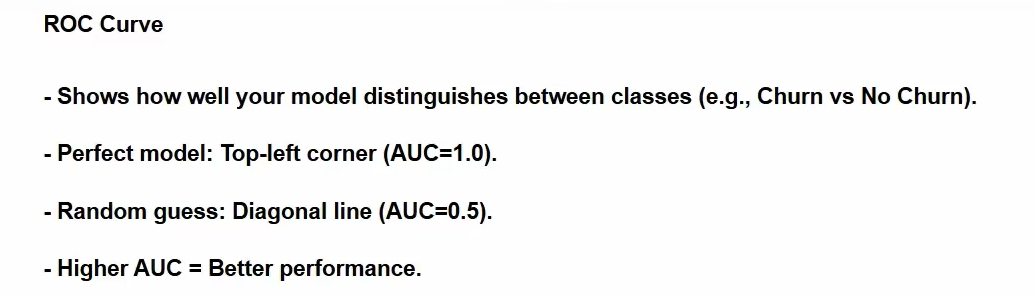

In [134]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_score

In [124]:
y_pred_p = model.predict_proba(X_test_rfe)

In [125]:
## cal ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_p[:, 1])

# roc_curve(Y_test, ...): This function calculates the False Positive Rates (FPR) and True Positive Rates (TPR) for the given
# ground truth labels (Y_test) and predicted scores.
    
# model.predict_proba(X_test_rfe)[:, 1]: model.predict_proba(X_test_rfe): Instead of predicting the final class (0 or 1), 
# this outputs the probability of belonging to each class. For binary classification, it returns an array of shape (n_samples, 2).

# [:, 1]: This slicing selects all rows (:) and the second column (1), which represents the predicted probability of the positive class (class 1).
    
# fpr (False Positive Rate): An array containing the FP / (FP + TN) for every distinct threshold, representing the proportion 
# of negative cases mistakenly classified as positive.
    
# tpr (True Positive Rate): An array containing the TP / (TP + FN) (also known as Sensitivity or Recall) for every threshold, 
# representing the proportion of positive cases correctly identified.
    
# thresholds: The probability values (0.0 to 1.0) used as cutoffs to decide between class 0 and class 1. 
# The roc_curve function tests many thresholds to see how they impact fpr and tpr.

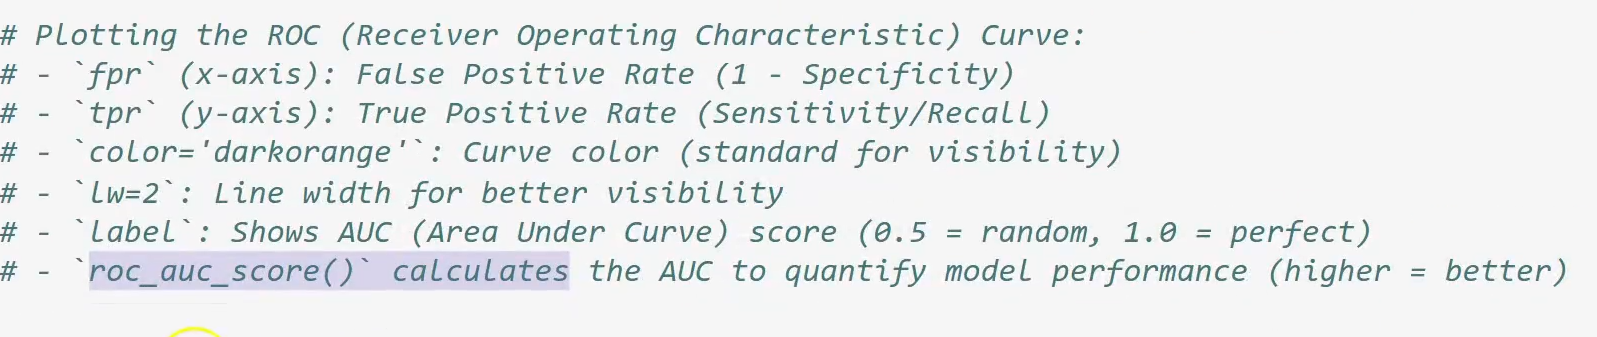

In [127]:
# plot the roc curve
roc_auc = roc_auc_score(Y_test, y_pred_p[:, 1])

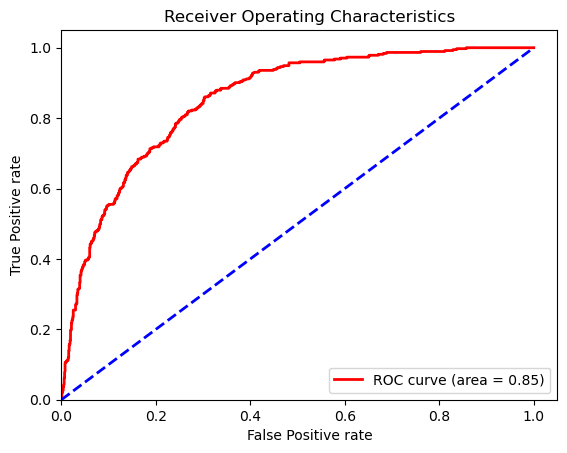

In [133]:
plt.plot(fpr, tpr, color = 'red', lw = 2, label = 'ROC curve (area = %0.2f)'% roc_auc)
plt.legend(loc = 'lower right')

plt.plot([0, 1], [0, 1], color = 'blue', lw = 2, linestyle = '--')
# This draws a diagonal line.
# Meaning:
#     This represents a random model.
#     If your ROC curve is above this line → model is good.
#     If it lies near this line → model is poor.
#     [0,1] [0,1] → coordinates of the diagonal line

plt.title('Receiver Operating Characteristics')
plt.xlabel('False Positive rate')
plt.xlim([0, 1.05])
plt.ylim([0, 1.05])
plt.ylabel('True Positive rate')
plt.show()

In [136]:
# cal precision and recall score
print('Recall score: ', recall_score(Y_test, y_pred_rfe))
print('Precision score: ', precision_score(Y_test, y_pred_rfe))

Recall score:  0.5442359249329759
Precision score:  0.6721854304635762
